## Exercise 5

In [14]:
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

from cookiedisaster.envs import CookieDisasterEnv

#### Task 2
##### Linear Q-function and Feature Design

In this part, we approximate the Q-function using a linear model instead of a Q-table. The idea is to represent each state-action pair with a feature vector and compute:

Q(s, a) = wᵀ φ(s, a)

where φ(s, a) contains useful information about the state and action, and w are the weights we learn.

The features include:
- robot position and velocity
- cookie position and remaining time
- distance between robot and cookie
- simple non-linear terms like velocity²
- indicators for whether the robot is moving toward or away from the cookie

We use **action-specific features**, meaning each action has its own set of weights. This allows the model to learn different behaviors for moving left, right, or staying still.

Feature engineering is important here because a linear model cannot learn complex relationships on its own, so we provide useful signals manually.

In [15]:
ACTIONS = [0, 1, 2]   # env actions: left, stay, right

class LinearQAgent:
    def __init__(self, alpha=0.01, gamma=0.99, epsilon=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        self.n_actions = 3
        self.n_base_features = 10
        self.n_features = self.n_actions * self.n_base_features

        self.w = np.zeros(self.n_features, dtype=np.float32)

    def unpack_state(self, obs):
        x = obs["agent"]["pos"]
        v = obs["agent"]["vel"]
        c = obs["cookie"]["pos"]
        t = obs["cookie"]["time"]
        return x, v, c, t

    def base_features(self, obs):
        x, v, c, t = self.unpack_state(obs)

        # normalization
        x_n = x / 10.0
        c_n = c / 10.0
        t_n = t / 5.0

        # choose a rough velocity scale for normalization
        v_scale = 5.0
        v_n = np.clip(v / v_scale, -2.0, 2.0)

        d = c - x
        d_n = d / 10.0
        abs_d_n = abs(d) / 10.0
        sign_d = np.sign(d)

        moving_toward = 1.0 if d * v > 0 else 0.0
        moving_away = 1.0 if d * v < 0 else 0.0

        return np.array([
            1.0,            # bias
            x_n,
            c_n,
            t_n,
            v_n,
            d_n,
            abs_d_n,
            v_n ** 2,
            moving_toward,
            moving_away,
        ], dtype=np.float32)

    def phi(self, obs, action):
        base = self.base_features(obs)
        features = np.zeros(self.n_features, dtype=np.float32)
        start = action * self.n_base_features
        end = start + self.n_base_features
        features[start:end] = base
        return features

    def q_value(self, obs, action):
        return np.dot(self.w, self.phi(obs, action))

    def best_action(self, obs):
        q_vals = [self.q_value(obs, a) for a in ACTIONS]
        return int(np.argmax(q_vals))

    def select_action(self, obs):
        if np.random.rand() < self.epsilon:
            return np.random.choice(ACTIONS)
        return self.best_action(obs)

    def update(self, obs, action, reward, next_obs, done):
        q_sa = self.q_value(obs, action)

        if done:
            target = reward
        else:
            target = reward + self.gamma * max(self.q_value(next_obs, a) for a in ACTIONS)

        td_error = target - q_sa
        self.w += self.alpha * td_error * self.phi(obs, action)

        return td_error

##### Q-learning with Linear Function Approximation

We train the agent using Q-learning with a linear approximation of the Q-function. Instead of updating a table, we update the weight vector w using the temporal-difference (TD) error.

At each step, we:
1. Select an action using an ε-greedy policy (random exploration + best known action)
2. Take a step in the environment
3. Compute the TD target:

   target = r + γ max_a' Q(s', a')

4. Update the weights:

   w ← w + α (target - Q(s, a)) φ(s, a)

This allows the agent to gradually learn which actions lead to higher rewards.

Since the task is continuing, we train over fixed-length episodes. Over time, the agent learns to move toward cookies efficiently while controlling its speed to avoid penalties.

In [16]:
env = CookieDisasterEnv(render_mode=None)
agent = LinearQAgent(alpha=0.01, gamma=0.99, epsilon=0.2)

num_episodes = 500
max_steps = 200

returns = []

for ep in range(num_episodes):
    obs, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        action = agent.select_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        agent.update(obs, action, reward, next_obs, done)

        obs = next_obs
        total_reward += reward

        if done:
            break

    returns.append(total_reward)

    # epsilon decay
    agent.epsilon = max(0.02, agent.epsilon * 0.995)

    if (ep + 1) % 50 == 0:
        avg_ret = np.mean(returns[-50:])
        print(f"Episode {ep+1}, avg return (last 50): {avg_ret:.3f}")

env.close()

Episode 50, avg return (last 50): 3.175
Episode 100, avg return (last 50): 7.344
Episode 150, avg return (last 50): 9.748
Episode 200, avg return (last 50): 10.098
Episode 250, avg return (last 50): 10.170
Episode 300, avg return (last 50): 10.384
Episode 350, avg return (last 50): 10.948
Episode 400, avg return (last 50): 10.592
Episode 450, avg return (last 50): 11.934
Episode 500, avg return (last 50): 12.304


#### Task 3

State preprocessing:

In [17]:
def state_to_vector(obs):
    x = obs["agent"]["pos"]
    v = obs["agent"]["vel"]
    c = obs["cookie"]["pos"]
    t = obs["cookie"]["time"]

    x_n = x / 10.0
    c_n = c / 10.0
    t_n = t / 5.0
    v_n = np.clip(v / 5.0, -2.0, 2.0)

    d = c - x
    d_n = d / 10.0
    abs_d_n = abs(d) / 10.0
    v2_n = v_n ** 2

    return np.array([x_n, v_n, c_n, t_n, d_n, abs_d_n, v2_n], dtype=np.float32)

NN from scratch: (without using libraries like PyTorch or TensorFlow)

In [18]:
class SimpleQNetwork:
    def __init__(self, input_dim=7, hidden_dim=32, output_dim=3, lr=0.001):
        self.lr = lr

        # Xavier-style initialization
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, hidden_dim))

        self.W3 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2 / hidden_dim)
        self.b3 = np.zeros((1, output_dim))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(np.float32)

    def forward(self, x):
        if x.ndim == 1:
            x = x.reshape(1, -1)

        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)

        self.z3 = self.a2 @ self.W3 + self.b3
        return self.z3

    def train_step(self, state, action, target):
        # Forward pass
        q_values = self.forward(state)              # shape (1, 3)
        prediction = q_values[0, action]

        # MSE loss only on chosen action
        loss = (prediction - target) ** 2

        # Gradient of loss wrt output
        dL_dz3 = np.zeros_like(q_values)
        dL_dz3[0, action] = 2 * (prediction - target)

        # Backprop
        dL_dW3 = self.a2.T @ dL_dz3
        dL_db3 = dL_dz3

        dL_da2 = dL_dz3 @ self.W3.T
        dL_dz2 = dL_da2 * self.relu_derivative(self.z2)

        dL_dW2 = self.a1.T @ dL_dz2
        dL_db2 = dL_dz2

        dL_da1 = dL_dz2 @ self.W2.T
        dL_dz1 = dL_da1 * self.relu_derivative(self.z1)

        dL_dW1 = self.x.T @ dL_dz1
        dL_db1 = dL_dz1

        # Gradient step
        self.W3 -= self.lr * dL_dW3
        self.b3 -= self.lr * dL_db3

        self.W2 -= self.lr * dL_dW2
        self.b2 -= self.lr * dL_db2

        self.W1 -= self.lr * dL_dW1
        self.b1 -= self.lr * dL_db1

        return float(loss)

    def predict(self, state):
        return self.forward(state).flatten()

agent:

In [19]:
class NeuralQAgent:
    def __init__(self, gamma=0.99, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995, lr=0.001):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_net = SimpleQNetwork(input_dim=7, hidden_dim=32, output_dim=3, lr=lr)

    def select_action(self, state_vec):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 3)
        q_values = self.q_net.predict(state_vec)
        return int(np.argmax(q_values))

    def update(self, state_vec, action, reward, next_state_vec, done):
        next_q = self.q_net.predict(next_state_vec)
        target = reward if done else reward + self.gamma * np.max(next_q)
        loss = self.q_net.train_step(state_vec, action, target)
        return loss

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

Training code:

In [20]:
env = CookieDisasterEnv(render_mode=None)


agent = NeuralQAgent(gamma=0.99, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995, lr=0.001)

num_episodes = 500
max_steps = 200

returns = []
losses = []

for ep in range(num_episodes):
    obs, info = env.reset()
    state_vec = state_to_vector(obs)

    total_reward = 0.0
    episode_losses = []

    for step in range(max_steps):
        action = agent.select_action(state_vec)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_state_vec = state_to_vector(next_obs)

        done = terminated or truncated
        loss = agent.update(state_vec, action, reward, next_state_vec, done)

        state_vec = next_state_vec
        total_reward += reward
        episode_losses.append(loss)

        if done:
            break

    agent.decay_epsilon()
    returns.append(total_reward)
    losses.append(np.mean(episode_losses))

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}, avg return (last 50): {np.mean(returns[-50:]):.3f}, avg loss: {np.mean(losses[-50:]):.4f}")

env.close()

Episode 50, avg return (last 50): -7.441, avg loss: 0.2352
Episode 100, avg return (last 50): -3.235, avg loss: 0.1480
Episode 150, avg return (last 50): -0.344, avg loss: 0.0748
Episode 200, avg return (last 50): 2.787, avg loss: 0.0776
Episode 250, avg return (last 50): 6.944, avg loss: 0.1018
Episode 300, avg return (last 50): 8.366, avg loss: 0.0593
Episode 350, avg return (last 50): 11.237, avg loss: 0.0549
Episode 400, avg return (last 50): 13.636, avg loss: 0.0503
Episode 450, avg return (last 50): 11.778, avg loss: 0.0405
Episode 500, avg return (last 50): 14.232, avg loss: 0.0446


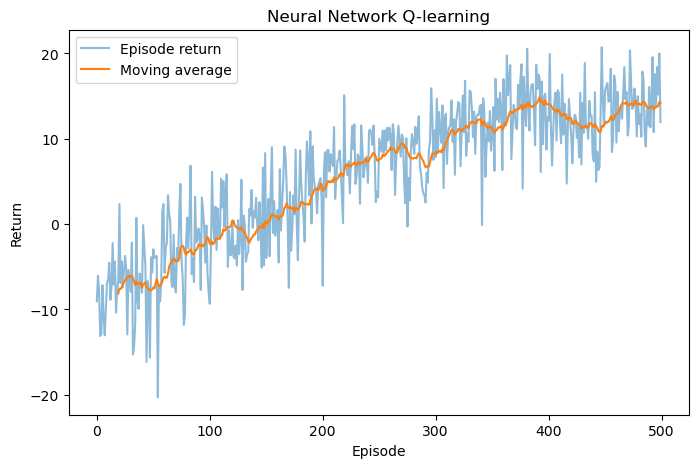

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(returns, alpha=0.5, label="Episode return")

window = 20
moving_avg = np.convolve(returns, np.ones(window)/window, mode='valid')
plt.plot(range(window - 1, len(returns)), moving_avg, label="Moving average")

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Neural Network Q-learning")
plt.legend()
plt.show()

#### Task 4

The linear model achieved higher performance, with average returns around $10$--$12$, while the neural network only reached approximately $3$ after the same amount of training.

The linear approximation performed better due to its simplicity and stability. With designed features, it was able to capture most of the relevant structure of the environment and learn efficiently from limited data.

In contrast, the neural network, although more expressive, was harder to train. The combination of Q-learning and function approximation leads to unstable targets, and without additional techniques such as replay buffers or target networks, learning is slower and less effective.

This shows that a simpler model can outperform a more complex one when training stability and data efficiency are important.


#### Task 5

Small neural network for the actor:
This outputs action probabilities.

##### Actor-Critic Model

In this part, we use an actor-critic method instead of Q-learning. The actor learns a policy directly, meaning it outputs probabilities for the three possible actions. The critic learns a value function that estimates how good each state is.

The actor and critic work together: the critic evaluates the current state, and the actor updates the policy based on this feedback.

In [22]:
class ActorNetwork:
    def __init__(self, input_dim=7, hidden_dim=32, output_dim=3, lr=0.001):
        self.lr = lr

        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(np.float32)

    def softmax(self, x):
        x = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, x):
        if x.ndim == 1:
            x = x.reshape(1, -1)

        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.probs = self.softmax(self.z2)
        return self.probs

    def sample_action(self, state):
        probs = self.forward(state).flatten()
        action = np.random.choice(len(probs), p=probs)
        return action, probs

    def train_step(self, state, action, advantage):
        probs = self.forward(state)  # shape (1, 3)

        # gradient of log pi(a|s) under softmax
        dlogits = probs.copy()
        dlogits[0, action] -= 1.0
        dlogits *= advantage  # gradient ascent on expected return

        dW2 = self.a1.T @ dlogits
        db2 = dlogits

        da1 = dlogits @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)

        dW1 = self.x.T @ dz1
        db1 = dz1

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

Small neural network for the critic:

This predicts V(s).

In [23]:
class CriticNetwork:
    def __init__(self, input_dim=7, hidden_dim=32, lr=0.005):
        self.lr = lr

        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, 1))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(np.float32)

    def forward(self, x):
        if x.ndim == 1:
            x = x.reshape(1, -1)

        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.v = self.a1 @ self.W2 + self.b2
        return self.v

    def predict(self, state):
        return float(self.forward(state)[0, 0])

    def train_step(self, state, target):
        value = self.forward(state)  # shape (1,1)
        error = value[0, 0] - target
        loss = error ** 2

        dvalue = np.array([[2 * error]], dtype=np.float32)

        dW2 = self.a1.T @ dvalue
        db2 = dvalue

        da1 = dvalue @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)

        dW1 = self.x.T @ dz1
        db1 = dz1

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        return float(loss)

actor critic agent

In [24]:
class ActorCriticAgent:
    def __init__(self, gamma=0.99, actor_lr=0.001, critic_lr=0.005):
        self.gamma = gamma
        self.actor = ActorNetwork(input_dim=7, hidden_dim=32, output_dim=3, lr=actor_lr)
        self.critic = CriticNetwork(input_dim=7, hidden_dim=32, lr=critic_lr)

    def select_action(self, state_vec):
        action, probs = self.actor.sample_action(state_vec)
        return action, probs

    def update(self, state_vec, action, reward, next_state_vec, done):
        v_s = self.critic.predict(state_vec)
        v_next = 0.0 if done else self.critic.predict(next_state_vec)

        td_target = reward + self.gamma * v_next
        td_error = td_target - v_s

        critic_loss = self.critic.train_step(state_vec, td_target)
        self.actor.train_step(state_vec, action, td_error)

        return critic_loss, td_error

training:


At each step, the agent samples an action from the policy, takes a step in the environment, and computes the temporal-difference (TD) error. The critic uses this error to improve its value estimate, while the actor uses it as a learning signal to increase the probability of better actions.

This allows the policy to be learned directly instead of first learning Q-values and then deriving a policy from them.

In [25]:
env = CookieDisasterEnv(render_mode=None)

agent = ActorCriticAgent(gamma=0.99, actor_lr=0.001, critic_lr=0.005)

num_episodes = 500
max_steps = 200

returns = []
critic_losses = []

for ep in range(num_episodes):
    obs, info = env.reset()
    state_vec = state_to_vector(obs)

    total_reward = 0.0
    episode_losses = []

    for step in range(max_steps):
        action, probs = agent.select_action(state_vec)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_state_vec = state_to_vector(next_obs)

        done = terminated or truncated
        critic_loss, td_error = agent.update(state_vec, action, reward, next_state_vec, done)

        state_vec = next_state_vec
        total_reward += reward
        episode_losses.append(critic_loss)

        if done:
            break

    returns.append(total_reward)
    critic_losses.append(np.mean(episode_losses))

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}, avg return (last 50): {np.mean(returns[-50:]):.3f}, avg critic loss: {np.mean(critic_losses[-50:]):.4f}")

env.close()

Episode 50, avg return (last 50): -4.676, avg critic loss: 0.0971
Episode 100, avg return (last 50): 0.229, avg critic loss: 0.0375
Episode 150, avg return (last 50): 3.240, avg critic loss: 0.0491
Episode 200, avg return (last 50): 5.809, avg critic loss: 0.0591
Episode 250, avg return (last 50): 7.637, avg critic loss: 0.0597
Episode 300, avg return (last 50): 9.816, avg critic loss: 0.0650
Episode 350, avg return (last 50): 11.466, avg critic loss: 0.0600
Episode 400, avg return (last 50): 12.357, avg critic loss: 0.0563
Episode 450, avg return (last 50): 13.438, avg critic loss: 0.0527
Episode 500, avg return (last 50): 13.798, avg critic loss: 0.0581


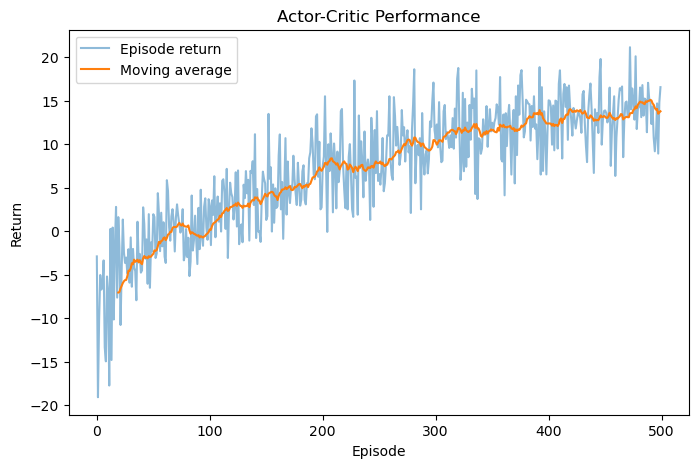

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(returns, alpha=0.5, label="Episode return")

window = 20
moving_avg = np.convolve(returns, np.ones(window) / window, mode='valid')
plt.plot(range(window - 1, len(returns)), moving_avg, label="Moving average")

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Actor-Critic Performance")
plt.legend()
plt.show()